In [1]:
# Montar el google drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# instalar UMAP
!pip install umap-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 3.2 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import random

from sklearn import datasets
from scipy.spatial import distance
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, QuantileTransformer, normalize
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn import metrics
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from matplotlib.patches import Ellipse, Polygon


In [4]:
housing_df = pd.read_csv('/content/drive/My Drive/Curso-UTEC-Estudiantes/Sec_7_Clustering/housing.csv', index_col=1)

In [5]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 60 to 20
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt     

In [6]:
housing_df['ExterQual']

,ExterQual
MSSubClass,
60,Gd
20,TA
60,Gd
70,TA
60,Gd
...,...
60,TA
20,TA
70,Ex


In [7]:
numeric_features     = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
                        'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
                        'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
                        'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
                        'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars',
                        'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
                        'ScreenPorch', 'PoolArea', 'MiscVal', 'YrSold']

numeric_features += ['SalePrice'] # treat this as a regular numeric feature here!!!

In [8]:
ordinal_features_reg = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                        'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
ordinal_features_oth = ['BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                        'Functional',  'Fence']
categorical_features = list(set(housing_df.columns) - set(numeric_features) - set(ordinal_features_reg))

ordering = ['Po', 'Fa', 'TA', 'Gd', 'Ex']

In [9]:
numeric_preprocessing = make_pipeline(SimpleImputer(strategy='median'),
                                      StandardScaler())

ordinal_preprocessing = make_pipeline(SimpleImputer(strategy='most_frequent'),
                                      OrdinalEncoder(categories=[ordering]*len(ordinal_features_reg)))

categorical_preprocessing = make_pipeline(SimpleImputer(strategy='constant', fill_value="?"),
                                          OneHotEncoder(handle_unknown='ignore', sparse_output=False))

In [10]:
preprocessing = ColumnTransformer([
    ('numeric', numeric_preprocessing, numeric_features),
    ('ordinal', ordinal_preprocessing, ordinal_features_reg),
    ('categorical', categorical_preprocessing, categorical_features)
])

In [11]:
preprocessing.fit(housing_df);

In [12]:

ohe_columns = list(preprocessing.named_transformers_['categorical'].named_steps['onehotencoder'].get_feature_names_out(categorical_features))
new_columns = numeric_features + ordinal_features_reg + ohe_columns

In [13]:
housing_df_enc = pd.DataFrame(preprocessing.transform(housing_df), index=housing_df.index, columns=new_columns)
housing_df_enc.shape

(1460, 1744)

## Podemos dividir estas 1460 casas en grupos similares?

Queremos agrupar las observaciones de forma que
* Los ejemplos del mismo grupo sean lo más parecidos posible;
* Los ejemplos de los distintos grupos sean lo más diferentes posible.

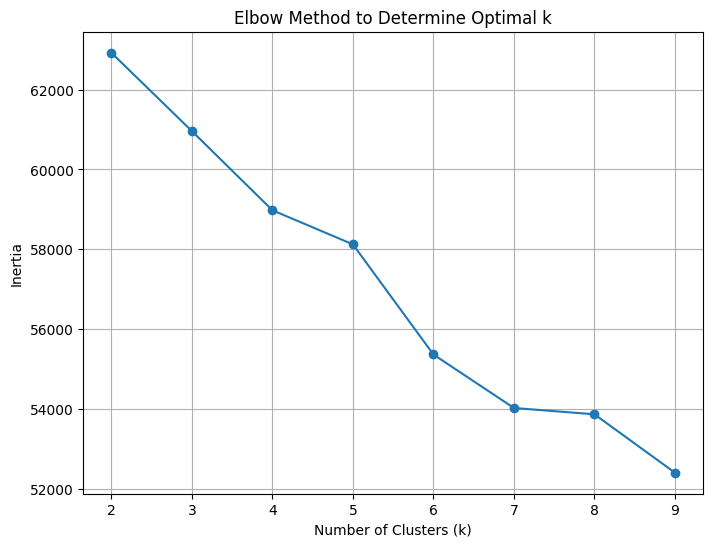

In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Range of k values to test
k_values = range(2, 10)
inertia_values = []

# Fitting KMeans for different k values and recording the inertia (sum of squared distances)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(housing_df_enc)
    inertia_values.append(kmeans.inertia_)

# Plotting the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia_values, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method to Determine Optimal k')
plt.grid(True)
plt.show()


In [15]:
kmeans = KMeans(n_clusters=5, random_state=1)
kmeans.fit(housing_df_enc);

In [16]:
kmeans.cluster_centers_

array([[ 1.02503544e+00,  9.56337378e-01,  1.58461127e+00, ...,
         2.29007634e-02,  5.20417043e-18,  1.62630326e-18],
       [ 1.31478168e-01,  4.31117555e-02, -5.52336387e-01, ...,
        -6.76542156e-17,  7.09219858e-03, -1.30104261e-18],
       [-1.32708432e-01, -1.75030479e-01,  7.16642789e-01, ...,
         4.50450450e-03,  2.25514052e-17,  2.05998413e-18],
       [-4.34562561e-01, -2.34372577e-01, -7.20390195e-01, ...,
         2.84237726e-02,  5.16795866e-03,  2.58397933e-03],
       [ 2.60675915e-02, -4.69950013e-02,  4.90742497e-01, ...,
         2.02020202e-02,  6.73400673e-03,  2.27682456e-18]])

In [17]:
kmeans.inertia_

56288.42030974245

In [18]:
preds = kmeans.predict(housing_df_enc)
preds

array([4, 1, 4, ..., 4, 1, 1], dtype=int32)

In [19]:
housing_raw_clust = housing_df.assign(cluster=preds)
housing_raw_clust

,Id,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,cluster
MSSubClass,,,,,,,,,,,,,,,,,,,,,
60,1,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,4
20,2,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,1
60,3,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,4
70,4,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,3
60,5,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,1456,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,8,2007,WD,Normal,175000,4
20,1457,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000,1
70,1458,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500,4


In [20]:
housing_raw_clust.query("cluster == 0")[["YearBuilt", "OverallQual", "SalePrice", "GrLivArea", "LotArea"]].mean()

,0
YearBuilt,1995.381679
OverallQual,8.290076
SalePrice,352459.740458
GrLivArea,2358.106870
LotArea,20059.015267


In [21]:
housing_raw_clust.query("cluster == 1")[["YearBuilt", "OverallQual", "SalePrice", "GrLivArea", "LotArea"]].mean()

,0
YearBuilt,1966.236407
OverallQual,5.335697
SalePrice,148849.867612
GrLivArea,1216.304965
LotArea,10946.990544


In [ ]:
housing_raw_clust.query("cluster == 2")[["YearBuilt", "OverallQual", "SalePrice", "GrLivArea", "LotArea"]].mean()

,0
YearBuilt,2001.585586
OverallQual,7.090090
SalePrice,212973.860360
GrLivArea,1452.211712
LotArea,8770.400901


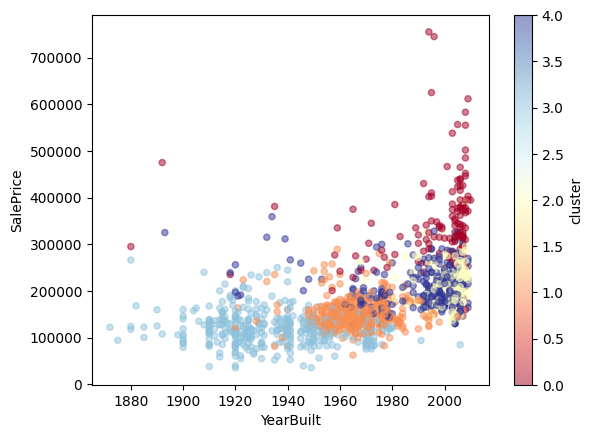

In [22]:
housing_raw_clust.plot.scatter(x="YearBuilt", y="SalePrice",
                               c="cluster", cmap="RdYlBu", alpha=0.5);

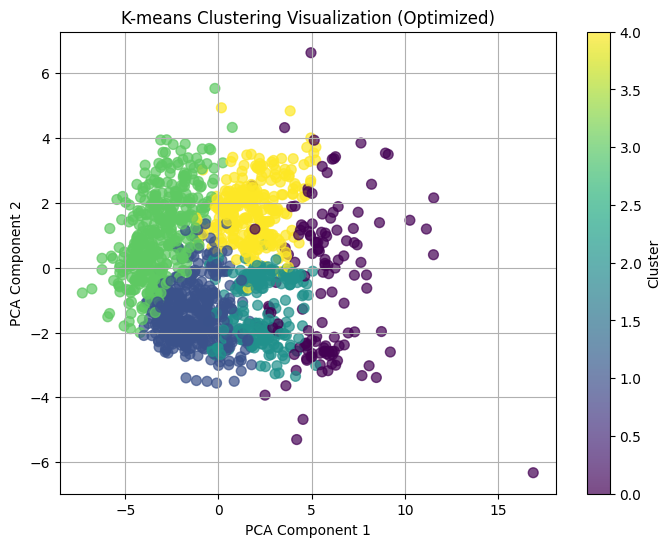

In [23]:
# Usar PCA para visualizar en 2D
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(housing_df_enc)

plt.figure(figsize=(8, 6))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=preds, cmap='viridis', s=50, alpha=0.7)
plt.title('K-means Clustering Visualization (Optimized)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

In [25]:
# Silhouette Score (Evaluación de Separación de Clusters)
silhouette_avg = silhouette_score(housing_df_enc, preds)
print("\nSilhouette Score promedio:", silhouette_avg)


Silhouette Score promedio: 0.06276394425151045


/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


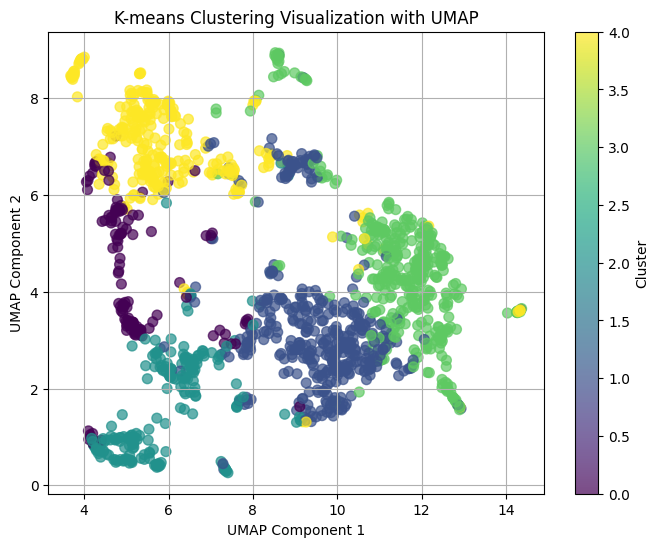

In [26]:

# Usar UMAP para visualizar en 2D
reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(housing_df_enc)

plt.figure(figsize=(8, 6))
plt.scatter(embedding[:, 0], embedding[:, 1], c=preds, cmap='viridis', s=50, alpha=0.7)
plt.title('K-means Clustering Visualization with UMAP')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

## DBSCAN


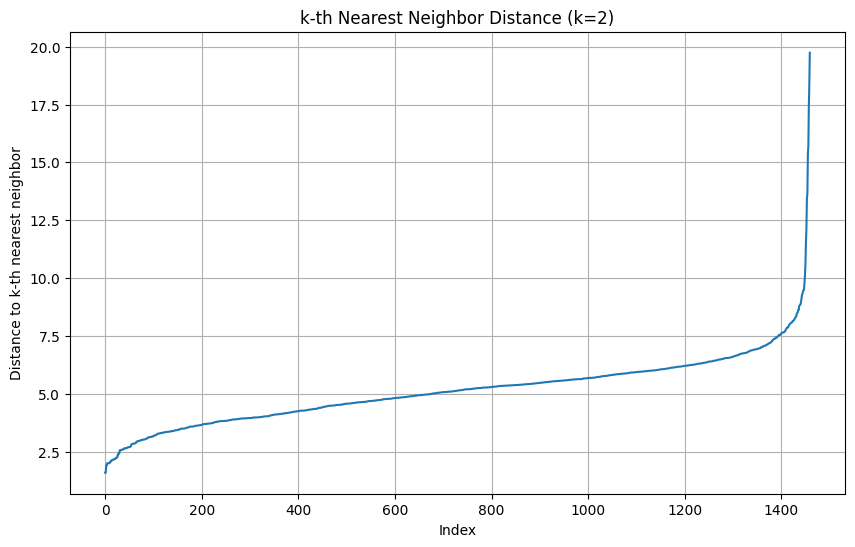

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors


min_samples = 2  # Puedes ajustar este valor según tu criterio

# Ajustamos de nuevo NearestNeighbors con el nuevo valor de min_samples, esta clase permite calcular los vecinos más cercanos para cada punto en los datos.

nn = NearestNeighbors(n_neighbors=min_samples)

nn.fit(housing_df_enc)

# Calculamos las distancias para el nuevo valor de min_samples
distances, indices = nn.kneighbors(housing_df_enc)

# Ordenamos las distancias y las graficamos
sorted_distances = np.sort(distances[:, -1])
plt.figure(figsize=(10, 6))
plt.plot(sorted_distances)
plt.xlabel('Index')
plt.ylabel('Distance to k-th nearest neighbor')
plt.title(f'k-th Nearest Neighbor Distance (k={min_samples})')
plt.grid(True)
plt.show()


La gráfica muestra las distancias al min_samples-ésimo vecino más cercano para cada punto. Al observar esta curva, buscamos un "codo" o un cambio abrupto en la pendiente. Este punto de inflexión sugiere un valor adecuado para eps.

**Antes del codo:** Los puntos tienen distancias pequeñas a sus vecinos más cercanos, lo que indica áreas densas en los datos.

**Después del codo:** Las distancias aumentan abruptamente, lo que sugiere que estamos empezando a ver puntos más alejados, posiblemente en áreas menos densas.

El punto donde ocurre este cambio en la pendiente es un buen candidato para el valor de eps en DBSCAN, ya que marca la distancia a partir de la cual los puntos están lo suficientemente separados para ser considerados como ruido o puntos fuera de clusters densos.

In [28]:
from sklearn.cluster import DBSCAN

# Definimos el modelo DBSCAN con los parámetros elegidos
dbscan = DBSCAN(eps=7.5, min_samples=2)

# Ajustamos el modelo a los datos preprocesados
clusters = dbscan.fit_predict(housing_df_enc)

# Veamos cuántos clusters se han formado y cuántos puntos se consideran ruido (label = -1)
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)

(n_clusters, n_noise)


(6, 66)

In [29]:
# Calcular el Silhouette Score excluyendo los puntos de ruido
silhouette_avg = silhouette_score(housing_df_enc[clusters != -1], clusters[clusters != -1])

print(f"Silhouette Score (excluyendo ruido): {silhouette_avg}")


Silhouette Score (excluyendo ruido): 0.11915898191298815


In [30]:
# Convertir las etiquetas de clusters en una serie y contar ocurrencias
cluster_sizes = pd.Series(clusters).value_counts()

print("Tamaño de cada cluster:\n", cluster_sizes)


Tamaño de cada cluster:
  0    1384
-1      66
 1       2
 2       2
 3       2
 4       2
 5       2
Name: count, dtype: int64


In [31]:
# Obtener las etiquetas de clusters
labels = dbscan.labels_
print("Etiquetas de clusters:", labels)

Etiquetas de clusters: [ 0  0  0 ... -1  0  0]


In [32]:
# 3. Obtener los puntos centrales en el espacio de características
components = dbscan.components_
print("Puntos núcleo en el espacio de características:\n", components)

Puntos núcleo en el espacio de características:
 [[-0.22087509 -0.20714171  0.65147924 ...  0.          0.
   0.        ]
 [ 0.46031974 -0.09188637 -0.07183611 ...  0.          0.
   0.        ]
 [-0.08463612  0.07347998  0.65147924 ...  0.          0.
   0.        ]
 ...
 [ 0.68738468  0.26640739 -0.07183611 ...  0.          0.
   0.        ]
 [-0.08463612 -0.08016039 -0.79515147 ...  0.          0.
   0.        ]
 [ 0.23325479 -0.05811155 -0.79515147 ...  0.          0.
   0.        ]]


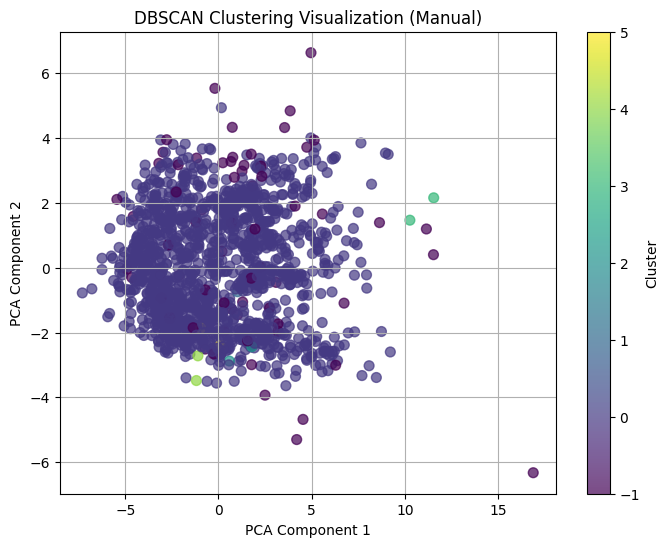

In [33]:
# Usar PCA para visualizar en 2D
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(housing_df_enc)

plt.figure(figsize=(8, 6))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.7)
plt.title('DBSCAN Clustering Visualization (Manual)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


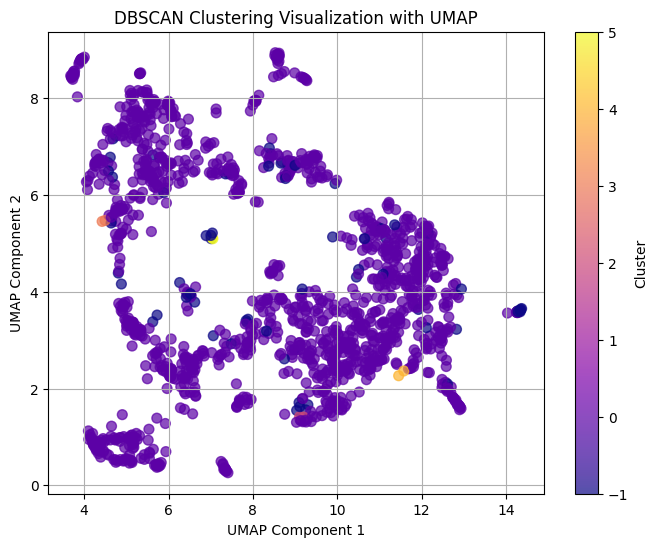

In [36]:
# Usar UMAP para visualizar en 2D
reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(housing_df_enc)

plt.figure(figsize=(8, 6))
plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='plasma', s=50, alpha=0.7)
plt.title('DBSCAN Clustering Visualization with UMAP')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

In [40]:
# prompt: Crear el UMAP en 3D dinamico

import plotly.express as px

# Usar UMAP para visualizar en 3D
reducer_3d = umap.UMAP(n_components=3, random_state=42)
embedding_3d = reducer_3d.fit_transform(housing_df_enc)



/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [39]:
# Crear el gráfico 3D interactivo con Plotly
fig = px.scatter_3d(
    x=embedding_3d[:, 0],
    y=embedding_3d[:, 1],
    z=embedding_3d[:, 2],
    # color=labels,  # Usar las etiquetas de DBSCAN para el color
    title='DBSCAN Clustering Visualization with UMAP (3D)',
    labels={'x': 'UMAP Component 1', 'y': 'UMAP Component 2', 'z': 'UMAP Component 3', 'color': 'Cluster'},
    opacity=0.7
)

fig.show()

In [ ]:
import numpy as np

# Definimos un rango de valores para eps y min_samples
eps_values = np.arange(3.0, 8.0, 0.2)  # Aumentamos eps desde 3.0 hasta 5.0
min_samples_values = range(2, 6)  # Probamos valores de min_samples desde 2 hasta 5


# Almacenamos los resultados en un diccionario para posterior visualización
results = {}

# Iteramos sobre los valores de eps y min_samples para calcular el silhouette score
for eps in eps_values:
    for min_samples in min_samples_values:
        # Aplicamos DBSCAN con los parámetros actuales
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        clusters = dbscan.fit_predict(housing_df_enc)

        # Si hay al menos 2 clusters (excluyendo ruido), calculamos el silhouette score
        # Se cambió la condición para requerir al menos 2 clusters
        n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
        if n_clusters >= 2:
            silhouette_score_value = silhouette_score(housing_df_enc[clusters != -1], clusters[clusters != -1])
            results[(eps, min_samples)] = silhouette_score_value

# Convertimos los resultados a un DataFrame para facilitar la visualización
results_df = pd.DataFrame(list(results.items()), columns=['Parameters', 'Silhouette Score'])

# Ordenamos los resultados por el mejor silhouette score
results_df_sorted = results_df.sort_values(by='Silhouette Score', ascending=False)

# Mostramos los mejores 5 resultados
results_df_sorted.head(5)

,Parameters,Silhouette Score
3,"(3.0, 5)",0.582410
7,"(3.2, 5)",0.569943
2,"(3.0, 4)",0.506693
1,"(3.0, 3)",0.445403
77,"(7.600000000000004, 2)",0.405293


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.8/362.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.2/233.2 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 3.6 MB/s eta 0:00:00


In [ ]:
# Función objetivo para Optuna
def objective(trial):
    # Sugerir hiperparámetros con un rango más amplio para eps
    eps = trial.suggest_float('eps', 0.1, 10.0)
    min_samples = trial.suggest_int('min_samples', 3, 50)

    # Aplicar DBSCAN con los hiperparámetros sugeridos
    dbscan_optuna = DBSCAN(eps=eps, min_samples=min_samples)

    # Ajustar el modelo
    labels_optuna = dbscan_optuna.fit_predict(housing_df_enc)

    # Si DBSCAN asigna todos los puntos como ruido (-1), devolver una penalización alta
    if len(set(labels_optuna)) <= 1:
        return float('inf')

    # Calcular la puntuación silhouette
    score = silhouette_score(housing_df_enc, labels_optuna)
    return score

# Crear y optimizar el estudio
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)  # Aumentamos a 50 ensayos para explorar más combinaciones

# Mostrar los mejores hiperparámetros
best_params = study.best_params
print("Mejores hiperparámetros encontrados:", best_params)

# Visualizar los clusters con los mejores parámetros
dbscan_best = DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples'])
labels_best = dbscan_best.fit_predict(housing_df_enc)


[I 2024-10-22 18:17:55,327] A new study created in memory with name: no-name-b2cb5dfa-f584-4ac1-a63d-dee299d05056
[I 2024-10-22 18:17:55,618] Trial 0 finished with value: inf and parameters: {'eps': 1.6871726546991315, 'min_samples': 25}. Best is trial 0 with value: inf.
[I 2024-10-22 18:17:56,177] Trial 1 finished with value: 0.549118053707527 and parameters: {'eps': 9.990032117994605, 'min_samples': 5}. Best is trial 0 with value: inf.
[I 2024-10-22 18:17:56,702] Trial 2 finished with value: 0.04405610914874802 and parameters: {'eps': 5.585656539280783, 'min_samples': 23}. Best is trial 0 with value: inf.
[I 2024-10-22 18:17:57,017] Trial 3 finished with value: inf and parameters: {'eps': 1.641137178552775, 'min_samples': 38}. Best is trial 0 with value: inf.
[I 2024-10-22 18:17:57,600] Trial 4 finished with value: 0.3010607985109692 and parameters: {'eps': 7.421616993160563, 'min_samples': 10}. Best is trial 0 with value: inf.
[I 2024-10-22 18:17:58,443] Trial 5 finished with value:

Mejores hiperparámetros encontrados: {'eps': 1.6871726546991315, 'min_samples': 25}


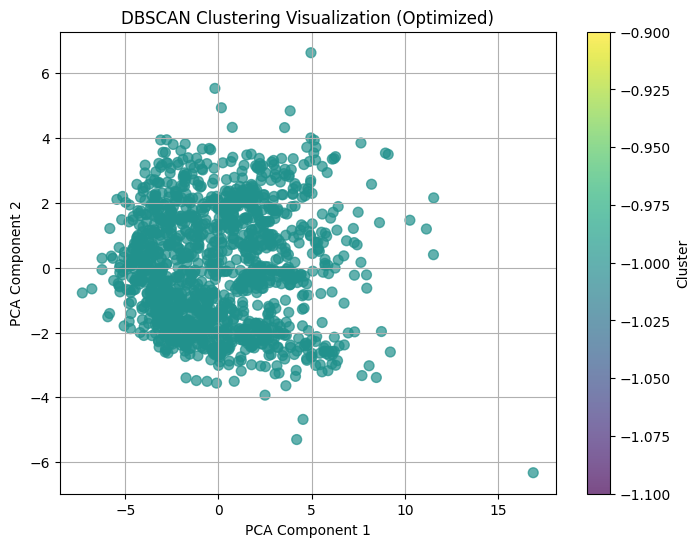

In [ ]:
# Usar PCA para visualizar en 2D
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(housing_df_enc)

plt.figure(figsize=(8, 6))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=labels_best, cmap='viridis', s=50, alpha=0.7)
plt.title('DBSCAN Clustering Visualization (Optimized)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

##  Cluster jerárquico

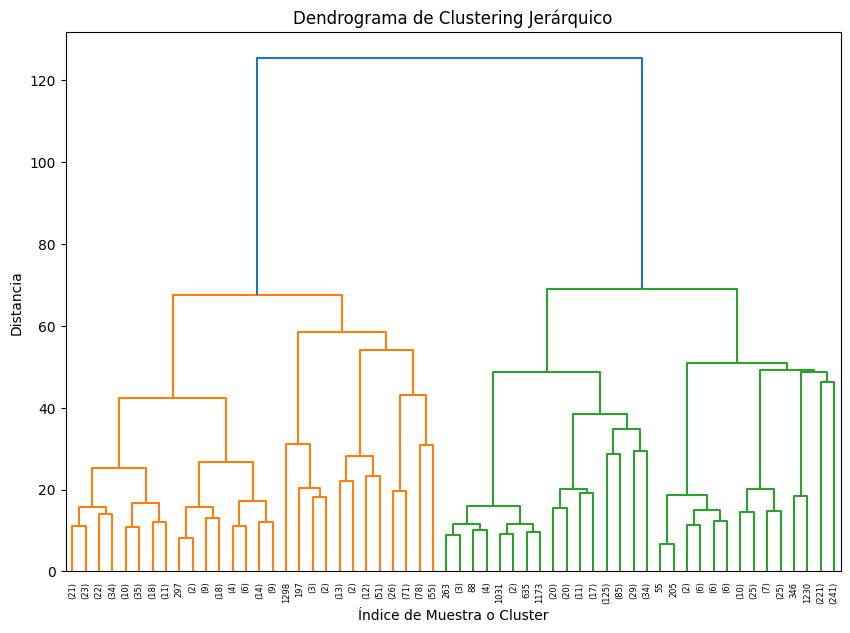

In [41]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt


# Visualización del dendrograma
linked = linkage(housing_df_enc, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(linked, truncate_mode='level', p=5)  # Ajusta "p" para ver más niveles
plt.title("Dendrograma de Clustering Jerárquico")
plt.xlabel("Índice de Muestra o Cluster")
plt.ylabel("Distancia")
plt.show()


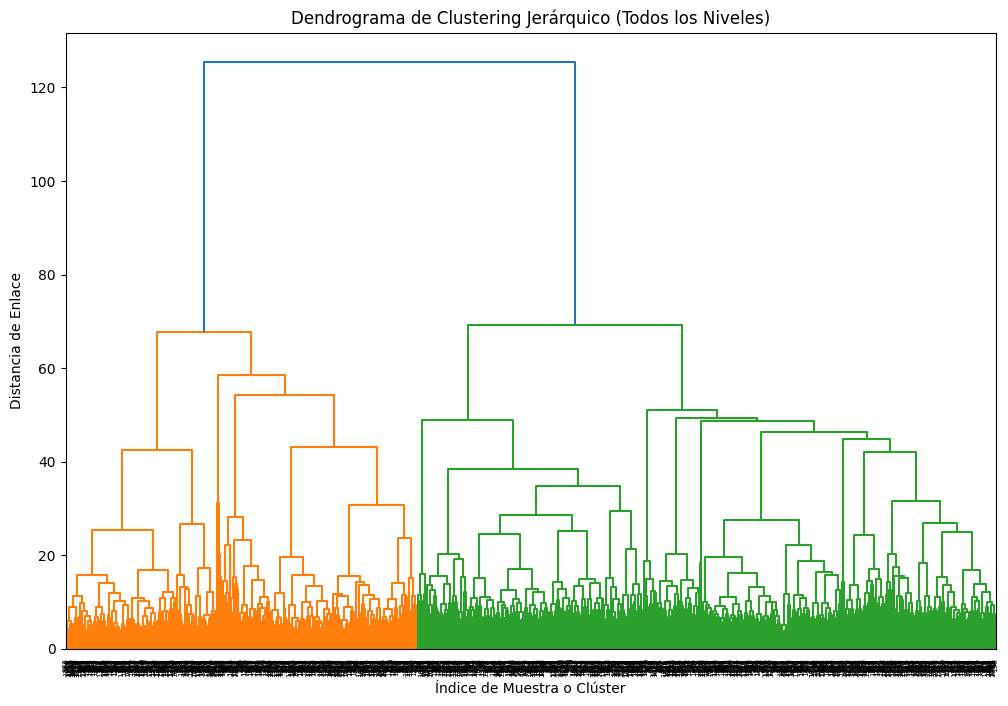

In [42]:
# Visualización completa del dendrograma
plt.figure(figsize=(12, 8))
dendrogram(linked)  # Sin 'truncate_mode' ni 'p'
plt.title("Dendrograma de Clustering Jerárquico (Todos los Niveles)")
plt.xlabel("Índice de Muestra o Clúster")
plt.ylabel("Distancia de Enlace")
plt.show()

In [43]:
# Definir el modelo de clustering jerárquico aglomerativo
model = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
model.fit(housing_df_enc)

# Etiquetas de los clusters
labels_1 = model.labels_


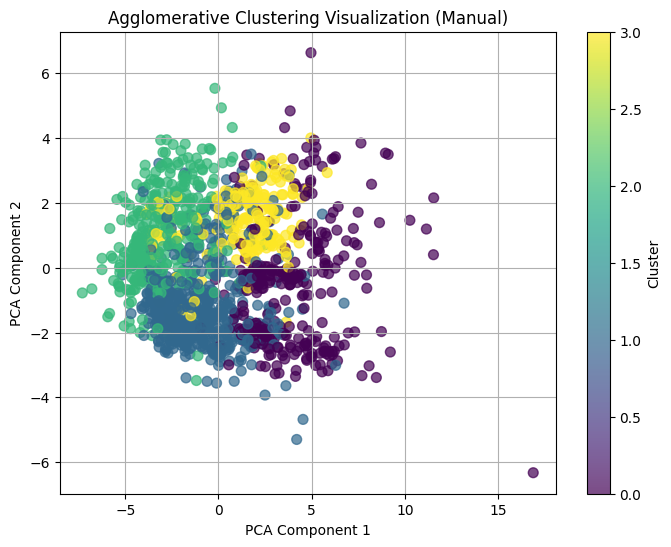

In [44]:
# Usar PCA para visualizar en 2D
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(housing_df_enc)

plt.figure(figsize=(8, 6))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=labels_1, cmap='viridis', s=50, alpha=0.7)
plt.title('Agglomerative Clustering Visualization (Manual)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



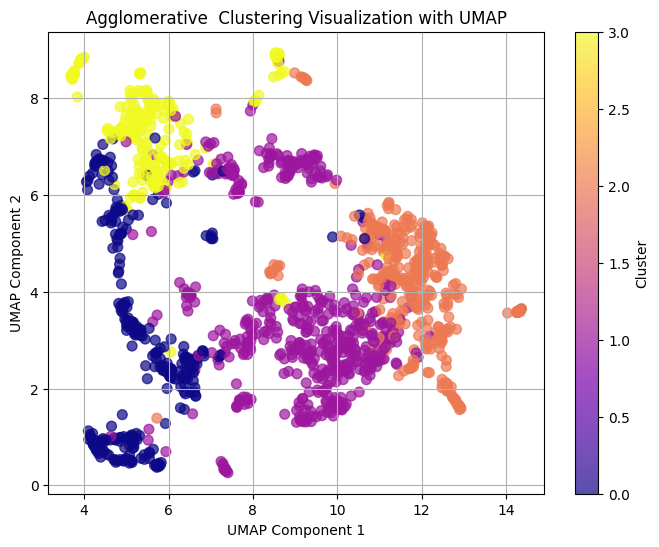

In [45]:
# Usar UMAP para visualizar en 2D
reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(housing_df_enc)

plt.figure(figsize=(8, 6))
plt.scatter(embedding[:, 0], embedding[:, 1], c=labels_1, cmap='plasma', s=50, alpha=0.7)
plt.title('Agglomerative  Clustering Visualization with UMAP')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

In [ ]:
import optuna
# Función objetivo para Optuna
def objective(trial):
    # Sugerir hiperparámetros
    n_clusters = trial.suggest_int('n_clusters', 2, 10)
    linkage = trial.suggest_categorical('linkage', ['ward', 'complete', 'average', 'single'])

    # Aplicar clustering aglomerativo con los hiperparámetros sugeridos
    agg_clustering_optuna = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)

    # Ajustar el modelo y calcular la puntuación silhouette
    labels_optuna = agg_clustering_optuna.fit_predict(housing_df_enc)
    score = silhouette_score(housing_df_enc, labels_optuna)
    return score

# Crear y optimizar el estudio
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

# Mostrar los mejores hiperparámetros
best_params = study.best_params
print("Mejores hiperparámetros encontrados:", best_params)

# Visualizar los clusters con los mejores parámetros
agg_clustering_best = AgglomerativeClustering(
    n_clusters=best_params['n_clusters'],
    linkage=best_params['linkage']
)
labels_best = agg_clustering_best.fit_predict(housing_df_enc)



[I 2024-10-28 15:54:41,609] A new study created in memory with name: no-name-db1a9b62-8857-412b-889e-e9dd3e3923c9
[I 2024-10-28 15:54:45,303] Trial 0 finished with value: 0.6733678034442285 and parameters: {'n_clusters': 3, 'linkage': 'single'}. Best is trial 0 with value: 0.6733678034442285.
[I 2024-10-28 15:54:47,486] Trial 1 finished with value: 0.05964061867095533 and parameters: {'n_clusters': 8, 'linkage': 'ward'}. Best is trial 0 with value: 0.6733678034442285.
[I 2024-10-28 15:54:49,702] Trial 2 finished with value: 0.08384443379968502 and parameters: {'n_clusters': 6, 'linkage': 'complete'}. Best is trial 0 with value: 0.6733678034442285.
[I 2024-10-28 15:54:51,085] Trial 3 finished with value: 0.4983604812414371 and parameters: {'n_clusters': 7, 'linkage': 'average'}. Best is trial 0 with value: 0.6733678034442285.
[I 2024-10-28 15:54:52,412] Trial 4 finished with value: 0.673710780071388 and parameters: {'n_clusters': 2, 'linkage': 'average'}. Best is trial 4 with value: 0.6

Mejores hiperparámetros encontrados: {'n_clusters': 2, 'linkage': 'average'}


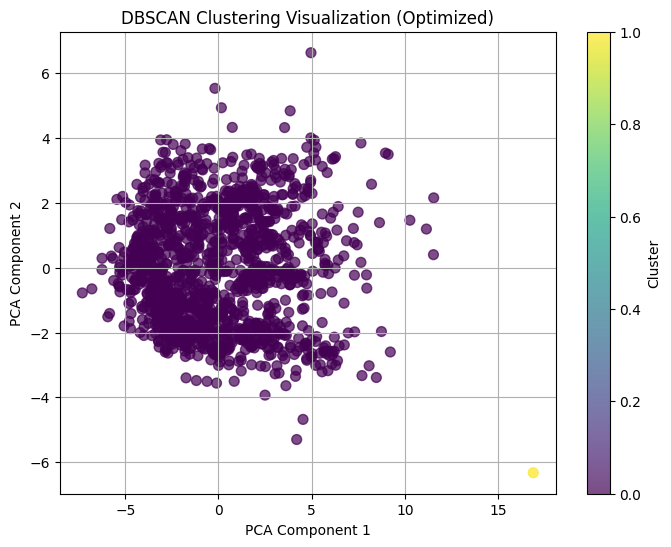

In [ ]:
# Usar PCA para visualizar en 2D
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(housing_df_enc)

plt.figure(figsize=(8, 6))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=labels_best, cmap='viridis', s=50, alpha=0.7)
plt.title('DBSCAN Clustering Visualization (Optimized)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()